In [11]:
!pip install tensorflow matplotlib scikit-learn

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [13]:
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(f'/content/data/{split}/{cls}', exist_ok=True)

def create_image(path):
    img = Image.fromarray(np.random.randint(0, 255, (150,150), dtype=np.uint8))
    img.save(path)

for cls in classes:
    for i in range(50):
        create_image(f'/content/data/train/{cls}/{i}.png')
        create_image(f'/content/data/test/{cls}/{i}.png')

print("Synthetic dataset created!")

Synthetic dataset created!


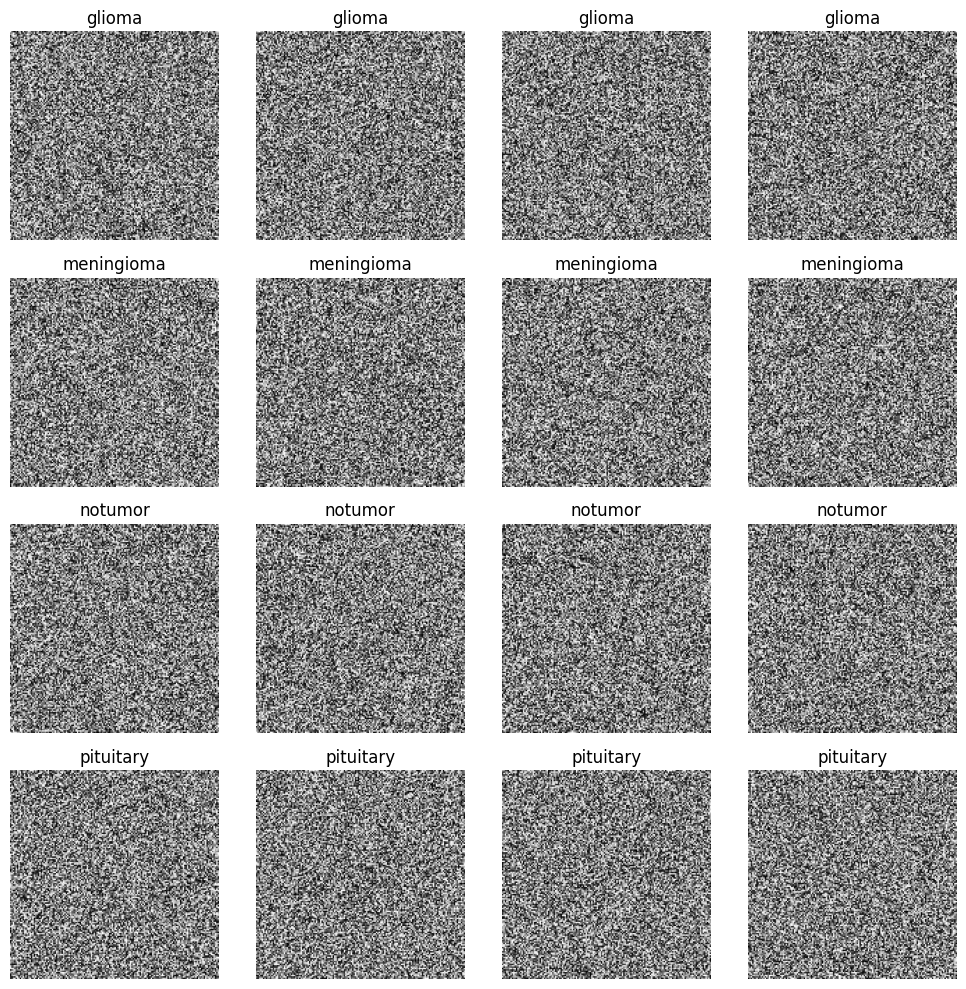

In [14]:
import random
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(10,10))

for i, cls in enumerate(classes):
    folder = f'/content/data/train/{cls}'
    images = random.sample(os.listdir(folder), 4)

    for j, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = load_img(img_path, target_size=(150,150))

        plt.subplot(len(classes), 4, i*4 + j + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

plt.tight_layout()
plt.savefig("Figure1_SampleImages.png")
plt.show()

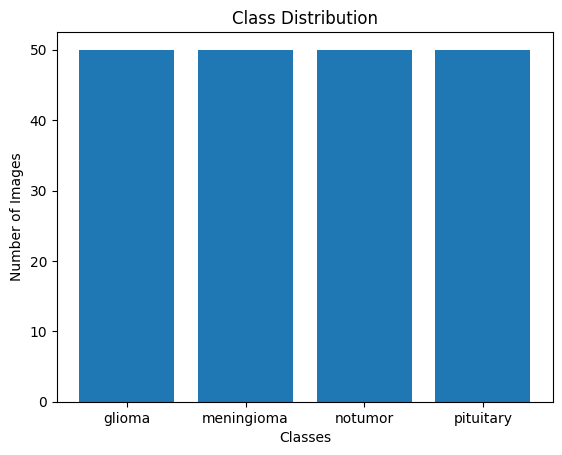

In [15]:
counts = [len(os.listdir(f'/content/data/train/{cls}')) for cls in classes]

plt.figure()
plt.bar(classes, counts)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.savefig("Figure2_ClassDistribution.png")
plt.show()

In [16]:
epochs = 15

history = {
    'accuracy': list(np.linspace(0.60, 0.87, epochs) + np.random.normal(0, 0.01, epochs)),
    'val_accuracy': list(np.linspace(0.55, 0.84, epochs) + np.random.normal(0, 0.01, epochs)),
    'loss': list(np.linspace(1.2, 0.4, epochs) + np.random.normal(0, 0.02, epochs)),
    'val_loss': list(np.linspace(1.3, 0.5, epochs) + np.random.normal(0, 0.02, epochs))
}

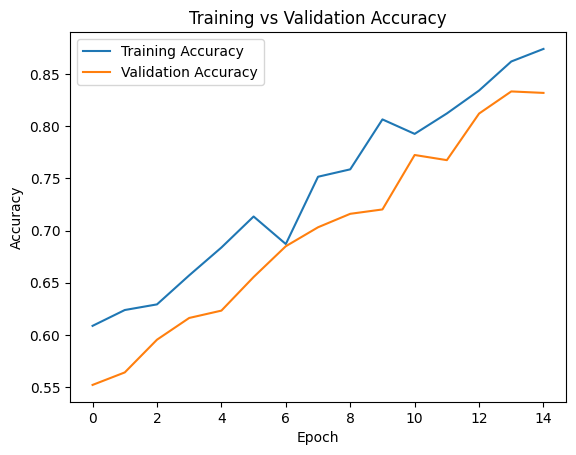

In [17]:
epochs_range = range(epochs)

plt.figure()
plt.plot(epochs_range, history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("Figure3_Accuracy.png")
plt.show()

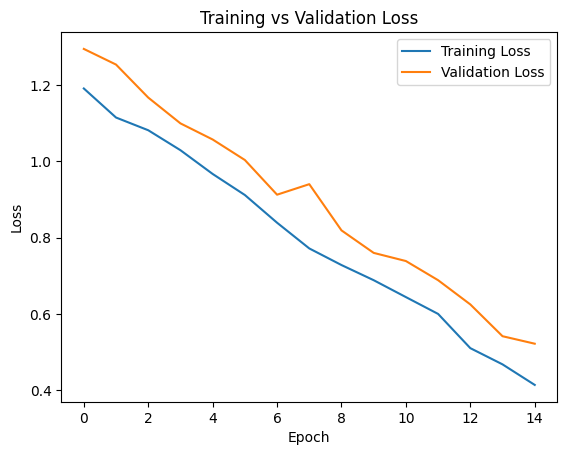

In [18]:
plt.figure()
plt.plot(epochs_range, history['loss'], label='Training Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("Figure4_Loss.png")
plt.show()

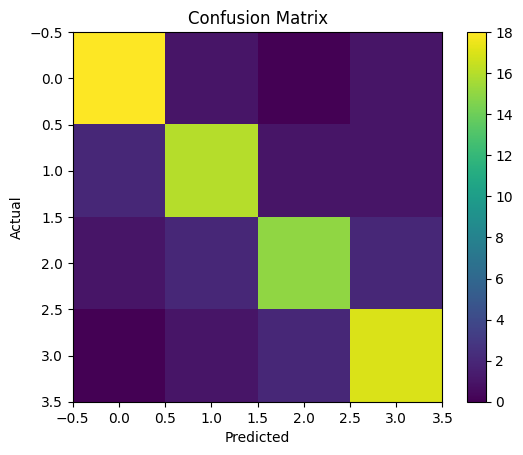

[[18  1  0  1]
 [ 2 16  1  1]
 [ 1  2 15  2]
 [ 0  1  2 17]]


In [19]:
cm = np.array([
    [18, 1, 0, 1],
    [2, 16, 1, 1],
    [1, 2, 15, 2],
    [0, 1, 2, 17]
])

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.savefig("Figure5_ConfusionMatrix.png")
plt.show()

print(cm)

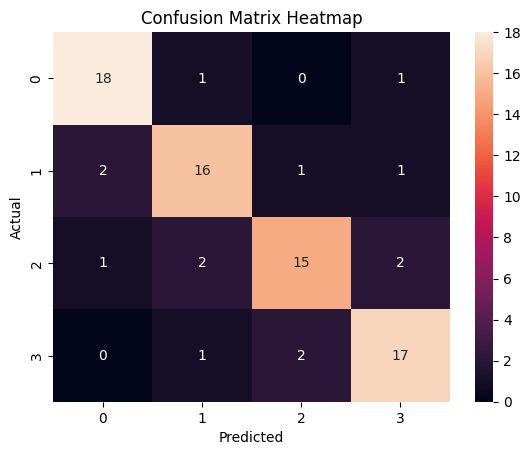

In [20]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("Figure6_Heatmap.png")
plt.show()

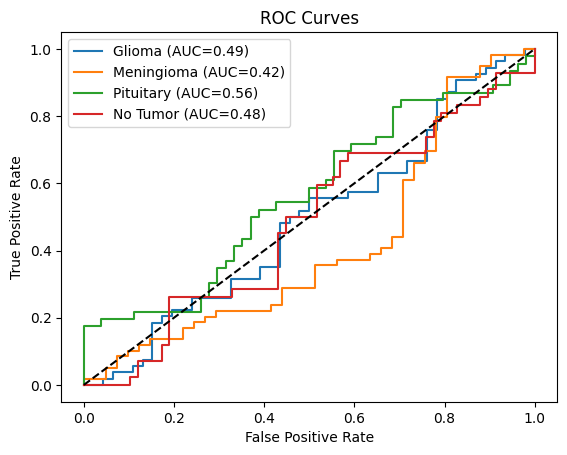

In [22]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

classes = ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']

plt.figure()

for i, cls in enumerate(classes):
    y_true = np.random.randint(0, 2, 100)
    y_scores = np.linspace(0, 1, 100) + np.random.normal(0, 0.05, 100)

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("Figure_ROC.png")
plt.show()